Data sources: [US Mortality DataBase for the USA](https://usa.mortality.org/national.php?national=USA), [for California](https://usa.mortality.org/state.php?state=CA), [for New York](https://usa.mortality.org/state.php?state=NY) / [U.S State Life Tables CSV + TXT 1941-2022](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/19WYUX)<br>
Outputs placed to wiki:<br>
[List of U.S. states and territories by life expectancy](https://en.wikipedia.org/wiki/List_of_U.S._states_and_territories_by_life_expectancy#Data_of_the_United_States_Mortality_DataBase) <i>([alternative](https://en.wikipedia.org/wiki/User:Lady3mlnm/List_of_U.S._states_and_territories_by_life_expectancy_(alternative)#Data_of_the_United_States_Mortality_DataBase))</i> / [Продолжительность жизни в штатах США](https://ru.wikipedia.org/wiki/Продолжительность_жизни_в_штатах_США#Данные_United_States_Mortality_DataBase)<br>
[Demographics of New York (state)](https://en.wikipedia.org/wiki/Demographics_of_New_York_(state)#Percentage_surviving), [Demographics of California](https://en.wikipedia.org/wiki/Demographics_of_California#Percentage_surviving), [Hawaii](https://en.wikipedia.org/wiki/Hawaii#Percentage_surviving)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import math
import re
from collections import namedtuple

In [3]:
pd.options.display.min_rows=8
# pd.options.display.max_rows=110

In [4]:
LANGS = ['en']  # languages of the charts (this setting doesn't have influence on tables)  #['en', 'ru', 'nolang']
YEAR = 2019
EXPLORE_PERIOD = True  # Change this value to 'False' to speed up work of the script, if the exploration is not required
WRITE_TABLE = False
DESTINATION_CHART = 'show'  # to where table code should be placed: 'file', 'show'

ST1 = 'NY'   # New York (state)
ST2 = 'CA'   # California
ST3 = 'HI'   # Hawaii

<br>

In [6]:
# For overview, explore probability of dying at certain age during a some period
def explore_change_of_probability_for_given_age(age_to_explore: str, level='Nationals', abbr='USA'):
    df_m = pd.read_csv(f"data/{level}/{abbr}/{abbr}_mltper_1x1.csv", sep=',', usecols=['Year', 'Age', 'qx'])
    df_m = df_m.loc[df_m['Age'] == age_to_explore] \
               .drop(columns='Age') \
               .set_index('Year') * 100
    
    df_t = pd.read_csv(f"data/{level}/{abbr}/{abbr}_bltper_1x1.csv", sep=',', usecols=['Year', 'Age', 'qx'])
    df_t = df_t.loc[df_t['Age'] == age_to_explore] \
               .drop(columns='Age') \
               .set_index('Year') * 100

    df_f = pd.read_csv(f"data/{level}/{abbr}/{abbr}_fltper_1x1.csv", sep=',', usecols=['Year', 'Age', 'qx'])
    df_f = df_f.loc[df_f['Age'] == age_to_explore] \
               .drop(columns='Age') \
               .set_index('Year') * 100

    df = pd.concat([df_m, df_t, df_f], axis='columns')
    df.index.name = ''
    df.columns = ('male', 'total', 'female')

    df['mΔf'] = df['male'] - df['female']     # No requirement for rounding since numbers are integers
    df['ratio_mf'] = (df['male'] / df['female']).round(2)
    
    return df

age_to_explore = '109'
df_to_explore = pd.DataFrame()
if EXPLORE_PERIOD:
    df_to_explore = explore_change_of_probability_for_given_age(age_to_explore)
df_to_explore.loc[2000:]

,male,total,female,mΔf,ratio_mf
,,,,,
2000,52.649,50.846,50.588,2.061,1.04
2001,52.636,50.971,50.735,1.901,1.04
2002,53.511,51.380,51.073,2.438,1.05
2003,53.336,51.699,51.459,1.877,1.04
2004,52.720,50.542,50.229,2.491,1.05
2005,53.386,51.439,51.157,2.229,1.04
2006,52.622,50.816,50.544,2.078,1.04
2007,52.405,50.505,50.222,2.183,1.04
2008,52.918,51.269,51.032,1.886,1.04


<br>

<h4>Basic calculations</h4>

In [8]:
DisplayedGroup = namedtuple('DisplayedGroup', ['en_name', 'ru_name', 'nolang_name', 'color', 'style', 'width', 'alpha'])

In [9]:
def load_data_single_unit(level, abbr, year, suffix_for_columns=''):  # , level='Nationals' / 'States'
    '''This function load data for probability of dying for a single state or a country as a whole'''
    df_m = pd.read_csv(f"data/{level}/{abbr}/{abbr}_mltper_1x1.csv", sep=',', usecols=['Year', 'Age', 'qx'])
    df_m = df_m.loc[df_m['Year'] == year] \
               .drop(columns='Year') \
               .set_index('Age') * 100
    df_m = df_m.rename(index={'110+': '110'}).rename(index=lambda st: int(st))
    
    df_t = pd.read_csv(f"data/{level}/{abbr}/{abbr}_bltper_1x1.csv", sep=',', usecols=['Year', 'Age', 'qx'])
    df_t = df_t.loc[df_t['Year'] == year] \
               .drop(columns='Year') \
               .set_index('Age') * 100
    df_t = df_t.rename(index={'110+': '110'}).rename(index=lambda st: int(st))

    df_f = pd.read_csv(f"data/{level}/{abbr}/{abbr}_fltper_1x1.csv", sep=',', usecols=['Year', 'Age', 'qx'])
    df_f = df_f.loc[df_f['Year'] == year] \
               .drop(columns='Year') \
               .set_index('Age') * 100
    df_f = df_f.rename(index={'110+': '110'}).rename(index=lambda st: int(st))

    df = pd.concat([df_m, df_t, df_f], axis='columns')
    df.index.name = ''
    df.columns = ('male', 'total', 'female')

    df['mΔf'] = df['male'] - df['female']     # No requirement for rounding since numbers are integers
    df['ratio_mf'] = (df['male'] / df['female']).round(2)

    df.columns = [f"{col_name}{suffix_for_columns}" for col_name in df.columns]

    return df


df = pd.concat([
        load_data_single_unit(level='Nationals', abbr='USA', year=YEAR),
        load_data_single_unit(level='States', abbr=ST1, year=YEAR, suffix_for_columns="_st1"),
        load_data_single_unit(level='States', abbr=ST2, year=YEAR, suffix_for_columns="_st2"),
        load_data_single_unit(level='States', abbr=ST3, year=YEAR, suffix_for_columns="_st3")], axis='columns')

# drop values for 110, since this record doesn't have sense
df.drop(index=110, inplace=True)

df.loc[[0, 1, 5]+list(range(10, 71, 10))+list(range(75, 106, 5))+[109]]

,male,total,female,mΔf,ratio_mf,male_st1,total_st1,female_st1,mΔf_st1,ratio_mf_st1,male_st2,total_st2,female_st2,mΔf_st2,ratio_mf_st2,male_st3,total_st3,female_st3,mΔf_st3,ratio_mf_st3
,,,,,,,,,,,,,,,,,,,,
0,0.601,0.552,0.499,0.102,1.20,0.482,0.422,0.359,0.123,1.34,0.442,0.410,0.376,0.066,1.18,0.544,0.505,0.464,0.080,1.17
1,0.042,0.038,0.035,0.007,1.20,0.023,0.023,0.023,0.000,1.00,0.032,0.028,0.023,0.009,1.39,0.104,0.059,0.012,0.092,8.67
5,0.014,0.013,0.012,0.002,1.17,0.015,0.013,0.012,0.003,1.25,0.010,0.010,0.010,0.000,1.00,0.011,0.017,0.023,-0.012,0.48
10,0.014,0.012,0.009,0.005,1.56,0.010,0.009,0.009,0.001,1.11,0.009,0.009,0.009,0.000,1.00,0.035,0.030,0.025,0.010,1.40
20,0.112,0.077,0.041,0.071,2.73,0.070,0.052,0.033,0.037,2.12,0.101,0.068,0.032,0.069,3.16,0.065,0.061,0.055,0.010,1.18
30,0.184,0.134,0.083,0.101,2.22,0.150,0.102,0.053,0.097,2.83,0.135,0.093,0.048,0.087,2.81,0.154,0.114,0.072,0.082,2.14
40,0.271,0.208,0.145,0.126,1.87,0.211,0.164,0.117,0.094,1.80,0.210,0.160,0.109,0.101,1.93,0.276,0.185,0.089,0.187,3.10
50,0.484,0.390,0.298,0.186,1.62,0.385,0.313,0.244,0.141,1.58,0.391,0.312,0.232,0.159,1.69,0.418,0.365,0.313,0.105,1.34
60,1.118,0.900,0.696,0.422,1.61,0.899,0.717,0.548,0.351,1.64,0.885,0.714,0.551,0.334,1.61,1.100,0.849,0.603,0.497,1.82


In [10]:
# alternative look at the result
df.loc[[0, 1, 5]+list(range(10, 71, 10))+list(range(75, 106, 5))+[109],
       ['male', 'male_st1', 'male_st2', 'male_st3', 'female', 'female_st1', 'female_st2', 'female_st3']]

,male,male_st1,male_st2,male_st3,female,female_st1,female_st2,female_st3
,,,,,,,,
0,0.601,0.482,0.442,0.544,0.499,0.359,0.376,0.464
1,0.042,0.023,0.032,0.104,0.035,0.023,0.023,0.012
5,0.014,0.015,0.010,0.011,0.012,0.012,0.010,0.023
10,0.014,0.010,0.009,0.035,0.009,0.009,0.009,0.025
20,0.112,0.070,0.101,0.065,0.041,0.033,0.032,0.055
30,0.184,0.150,0.135,0.154,0.083,0.053,0.048,0.072
40,0.271,0.211,0.210,0.276,0.145,0.117,0.109,0.089
50,0.484,0.385,0.391,0.418,0.298,0.244,0.232,0.313
60,1.118,0.899,0.885,1.100,0.696,0.548,0.551,0.603


<br>
<br>

<br>

<h4>Explore the "plateau"  (21–30 years)</h4>
The code below calculates average values of the probability of dying for the "plateau", and how much people would live if throughout their lifetime the probability of dying will be the same as in this interval.

In [13]:
# explore the the "plateau" manually, if we want
# df.loc[16:40]

In [14]:
# just for fun, calculate average values during the "plateau" for the country and the separate regions
plateau_years = slice(21, 30)

dfe = pd.concat([
    df.loc[plateau_years, ['male', 'total', 'female']].mean(),
    df.loc[plateau_years, ['male_st1', 'total_st1', 'female_st1']].mean().rename(index={'male_st1':'male', 'total_st1':'total', 'female_st1':'female'}),
    df.loc[plateau_years, ['male_st2', 'total_st2', 'female_st2']].mean().rename(index={'male_st2':'male', 'total_st2':'total', 'female_st2':'female'}),
    df.loc[plateau_years, ['male_st3', 'total_st3', 'female_st3']].mean().rename(index={'male_st3':'male', 'total_st3':'total', 'female_st3':'female'})
], axis='columns').T
dfe['ratio_mf'] = (dfe['male'] / dfe['female']).round(2)
dfe.index = ['USA', ST1, ST2, ST3]
dfe.round(3)

,male,total,female,ratio_mf
USA,0.154,0.108,0.061,2.51
NY,0.115,0.080,0.045,2.58
CA,0.122,0.083,0.042,2.92
HI,0.096,0.071,0.043,2.24


In [15]:
# calculate average life expectancy if during the whole life of people the mortality rate will the the same as at the "plateau"
def calculate_average_LE_if_mortality_as_at_plateau(mortality_in_perc):
    mortality = mortality_in_perc / 100
    average_le = 1 / mortality
    return int(average_le)

dfe['le_ageless_male'] = dfe['male'].map(calculate_average_LE_if_mortality_as_at_plateau)
dfe['le_ageless_total'] = dfe['total'].map(calculate_average_LE_if_mortality_as_at_plateau)
dfe['le_ageless_female'] = dfe['female'].map(calculate_average_LE_if_mortality_as_at_plateau)
# dfe['ratio_ageless'] = (dfe['le_ageless_female'] / dfe['le_ageless_male']).round(2)  # values the same as in the columns 'ratio_mf'
dfe.round(3)

,male,total,female,ratio_mf,le_ageless_male,le_ageless_total,le_ageless_female
USA,0.154,0.108,0.061,2.51,650,924,1633
NY,0.115,0.080,0.045,2.58,868,1253,2242
CA,0.122,0.083,0.042,2.92,820,1203,2392
HI,0.096,0.071,0.043,2.24,1037,1404,2325


<br>

<h4>Explore the zone of the Gompertz law of mortality  (40–90 years)</h4>
The code below calculates the average annual increase the probability of dying (in percent) and the period during that this indicator doubles (in years).

In [17]:
def calculate_increase_rate_and_doubling_period(age1: int, age2: int, v1: float, v2: float):
    '''
    This function calculate two characteristics of a geometric progression (in the context of aging)
    - by what percentage does the value increase every year (in percent)
    - period of doubling (in years)
    '''
    q = math.pow((v2 / v1),
                  1 / (age2 - age1))  # find 'common ratio' of the geometric progression
                                      # (age2 - age1) √ (v2 / v1)      – (age2-age1)th root of (v2 / v1)

    T = math.log(2, q)  # doubling period:    log base 'q' of 2
    return (q - 1) * 100, T

In [18]:
age1 = 40
age2 = 90
print("increase_rate(%)   doubling   | increase_rate(%)   doubling")
print("             male             |             female")
for region, pref in zip(['USA', ST1, ST2, ST3], ['', '_st1', '_st2', '_st3']): 
    male_rate_perc, male_period_double = \
        calculate_increase_rate_and_doubling_period(age1, age2, df.loc[age1, 'male'+pref], df.loc[age2, 'male'+pref])
    female_rate_perc, female_period_double = \
        calculate_increase_rate_and_doubling_period(age1, age2, df.loc[age1, 'female'+pref], df.loc[age2, 'female'+pref])
    print(f"{region:3}: {male_rate_perc:6.3f} %  {male_period_double:6.3f} years   |" +
          f"      {female_rate_perc:6.3f} %  {female_period_double:6.3f} years")

increase_rate(%)   doubling   | increase_rate(%)   doubling
             male             |             female
USA:  8.456 %   8.539 years   |       9.343 %   7.760 years
NY :  8.785 %   8.231 years   |       9.542 %   7.606 years
CA :  8.823 %   8.197 years   |       9.751 %   7.450 years
HI :  7.976 %   9.033 years   |       9.728 %   7.467 years


<br>

In [20]:
# Code in this cell generates an extended table about probability of dying in the United States as a whole and states
# (by default, these are New York, California, and Hawaii)

def create_table(df, file_header, lang='en'):

    def transform_value(x, prec=1):
        return f"{x:0.{prec}f}"

    
    with open('design/' + file_header, mode='r', encoding="utf-8") as fh:
        table_header = fh.read()

    st = ''
    prec = 3
    for age in [1] + list(range(5, 106, 5)) + [109]:
        ser = df.loc[age]
        st += '\n' + '|-\n' + \
            f'|style="padding-right:3ex;"| {age} ' + \
            f'||style="color:blue;padding-right:3ex;"| {transform_value(ser.loc['male'], prec=prec)} ' + \
            f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['female'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {ser.loc['ratio_mf']:0.2f} ' + \
            f'||style="color:blue;padding-right:3ex;border-left-width:2px;"| {transform_value(ser.loc['male_st1'], prec=prec)} ' + \
            f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['female_st1'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {ser.loc['ratio_mf_st1']:0.2f} ' + \
            f'||style="color:blue;padding-right:3ex;border-left-width:2px;"| {transform_value(ser.loc['male_st2'], prec=prec)} ' + \
            f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['female_st2'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {ser.loc['ratio_mf_st2']:0.2f} ' + \
            f'||style="color:blue;padding-right:3ex;border-left-width:2px;"| {transform_value(ser.loc['male_st3'], prec=prec)} ' + \
            f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['female_st3'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {ser.loc['ratio_mf_st3']:0.2f}'

    # fix microbugs that can happened due to nuances of calculations and rounding
    st = st.replace('color:darkgray;padding-right:3ex;"| -0.0 ', 'color:darkgray;padding-right:3ex;"| 0.0 ')

    if lang == 'ru':
        st = re.sub('(?<=\\d)\\.(?=\\d)', ',', st)  # replace . to comma, if this . is between two digits
        st = st.replace('padding-right:3ex;', 'padding-right:2.5ex;')

    st = table_header + st + '\n|}'
    return st
        

if WRITE_TABLE:
    table_code = create_table(df, file_header='Probability_of_dying_extended -en.txt', lang='en')
    with open(f"output/Table code for probability of dying extended -{YEAR} -en.txt", 'w', encoding="utf-8") as fh:
        fh.write(table_code)
        
    table_code = create_table(df, file_header='Probability_of_dying_extended -ru.txt', lang='ru')
    with open(f"output/Table code for probability of dying extended -{YEAR} -ru.txt", 'w', encoding="utf-8") as fh:
        fh.write(table_code)

<br>
<br>

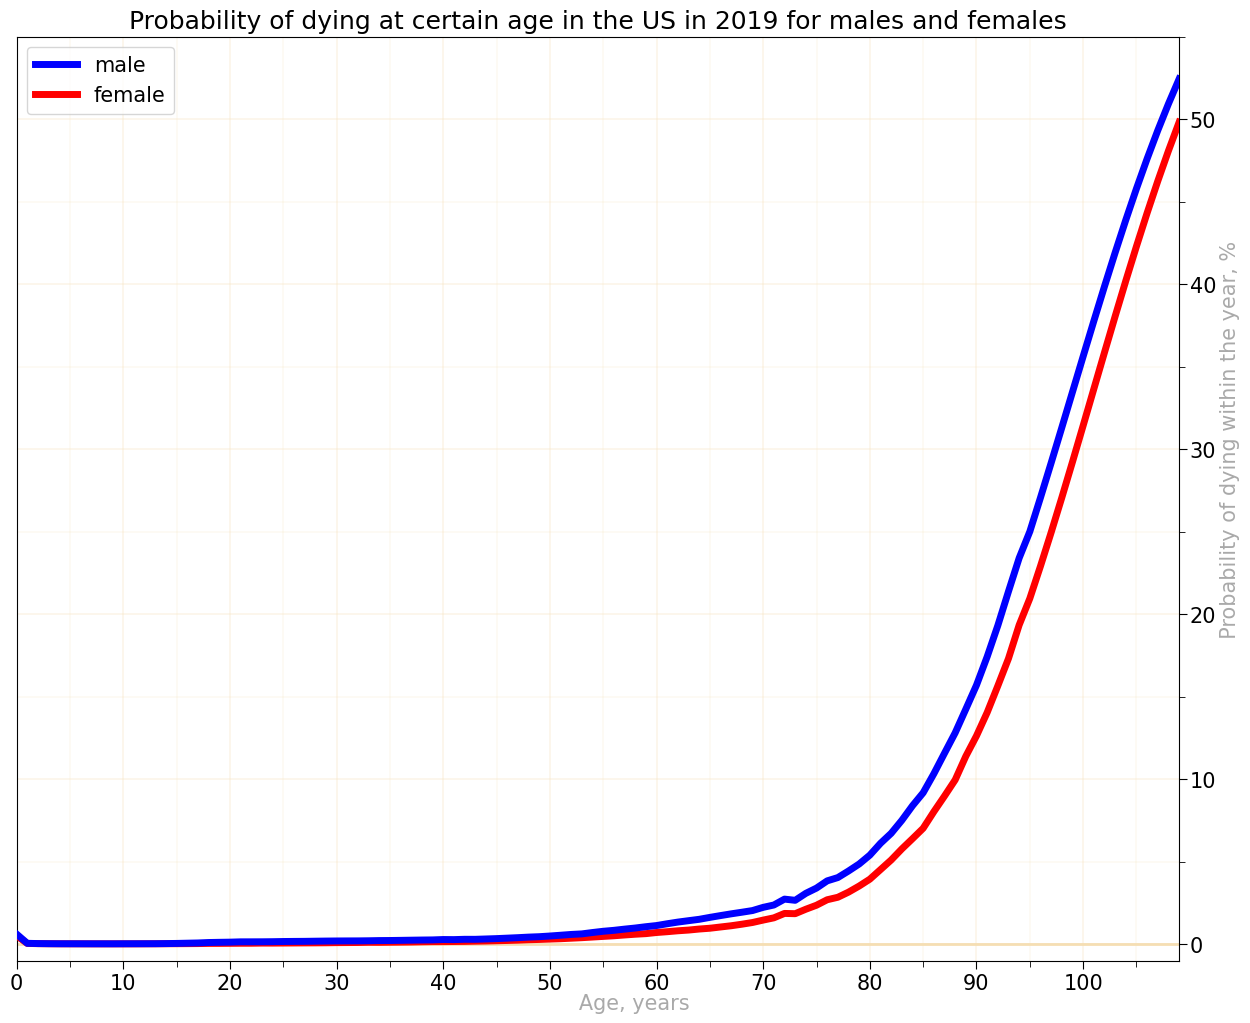

In [22]:
def create_chart(
        df, lang='en', dd_display='', ncol=1,
        title_en="Title of the chart", title_ru="Заголовок графика",
        destination=DESTINATION_CHART, file_name=''):

    plt.rcParams['figure.figsize'] = (15, 12)
    
    fig, ax = plt.subplots()   # Create a figure and axis
    ax.yaxis.tick_right()      # show ticks only at the left side
    ax.yaxis.set_label_position('right')  # set the label position to the right 

    ax.xaxis.set_major_locator(MultipleLocator(10))   # Set major ticks to be multiples of 10
    ax.xaxis.set_minor_locator(MultipleLocator(5))    # Set minor ticks to be multiples of 5
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_minor_locator(MultipleLocator(5))

    # Customize tick lengths
    ax.tick_params(axis='x', which='major', length=6, pad=3)  # Major ticks are longer
    ax.tick_params(axis='x', which='minor', length=4)  # Minor ticks are shorter
    ax.tick_params(axis='y', which='major', length=6, pad=1.5)  # Major ticks are longer
    ax.tick_params(axis='y', which='minor', length=4)  # Minor ticks are shorter
    plt.xticks(fontsize=15)  # font size for tick labels
    plt.yticks(fontsize=15)
    
    x_min = y_min = 0
    x_max = 109
    y_max = 55
    plt.xlim(0, 109)
    plt.ylim(-1, 55)

    plt.grid(which='major', color='wheat', linewidth=0.35)
    plt.grid(which='minor', color='wheat', linewidth=0.20)

    plt.axhline(y=0, color='wheat', linewidth=2)

    plt.title(title_ru if lang=='ru' else " " if lang=='nolang' else title_en, fontsize=18)
    plt.xlabel("               Возраст, годы" if lang=='ru' else
               " " if lang=='nolang' else
               "           Age, years",
               fontsize=15, color='darkgray', labelpad=0)
    plt.ylabel("          Вероятность смерти в течение года, %" if lang=='ru' else
               " " if lang=='nolang' else
               "                  Probability of dying within the year, %",
               fontsize=15, color='darkgray', labelpad=3)
    
    for i, gr in enumerate(df.index.to_list()):
        ser = df.loc[gr]
        line_name = dd_display[gr].ru_name if lang=='ru' else dd_display[gr].nolang_name if lang=='nolang' else dd_display[gr].en_name
        plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
                 linewidth=dd_display[gr].width, label=line_name, alpha=dd_display[gr].alpha, zorder=100-i)

    plt.legend(loc='upper left', fontsize=15, ncol=ncol)

    if destination == 'file':
        plt.savefig(f"output_charts/{file_name}{' -ru' if lang=='ru' else ' -nolang' if lang=='nolang' else ''}.png", bbox_inches='tight', facecolor='white', pad_inches=0.05)
        print("Data has written to file")
    else:
        plt.show()


dd_display = {
    'male'  : DisplayedGroup(en_name="male",    ru_name="мужчины", nolang_name="♂", color='blue',      style='-', width=5, alpha=1),
    # 'total' : DisplayedGroup(en_name="overall", ru_name="в целом", nolang_name="∑", color='lightgrey', style='-', width=5, alpha=1),
    'female': DisplayedGroup(en_name="female",  ru_name="женщины", nolang_name="♀", color='red',       style='-', width=5, alpha=1)
}

for lang in LANGS:
    create_chart(df.T.loc[['male', 'female']],
                 dd_display=dd_display, lang=lang,
                 title_en=f"Probability of dying at certain age in the US in {YEAR} for males and females",  # , overall statistics for males and females
                 title_ru=f"Вероятность смерти в определённом возрасте в США в {YEAR} для мужчин и женщин",
                 file_name=f"Probability of Dying at Certain Age in the US in {YEAR}")

  —— The zone of the 'plateau' (21–30 years, incl.) ——
Average mortality rate at the plateau, %:  ♂: 0.154,  ♀: 0.061
Average life expectancy, if the mortality rate was the same as at the plateau, years:  ♂: 650,  ♀: 1630
  —— The zone of the Gompertz law of mortality (40–90 years) ——
♂:  8.46 %/years,  doubling every 8.54 years
♀:  9.34 %/years,  doubling every 7.76 years


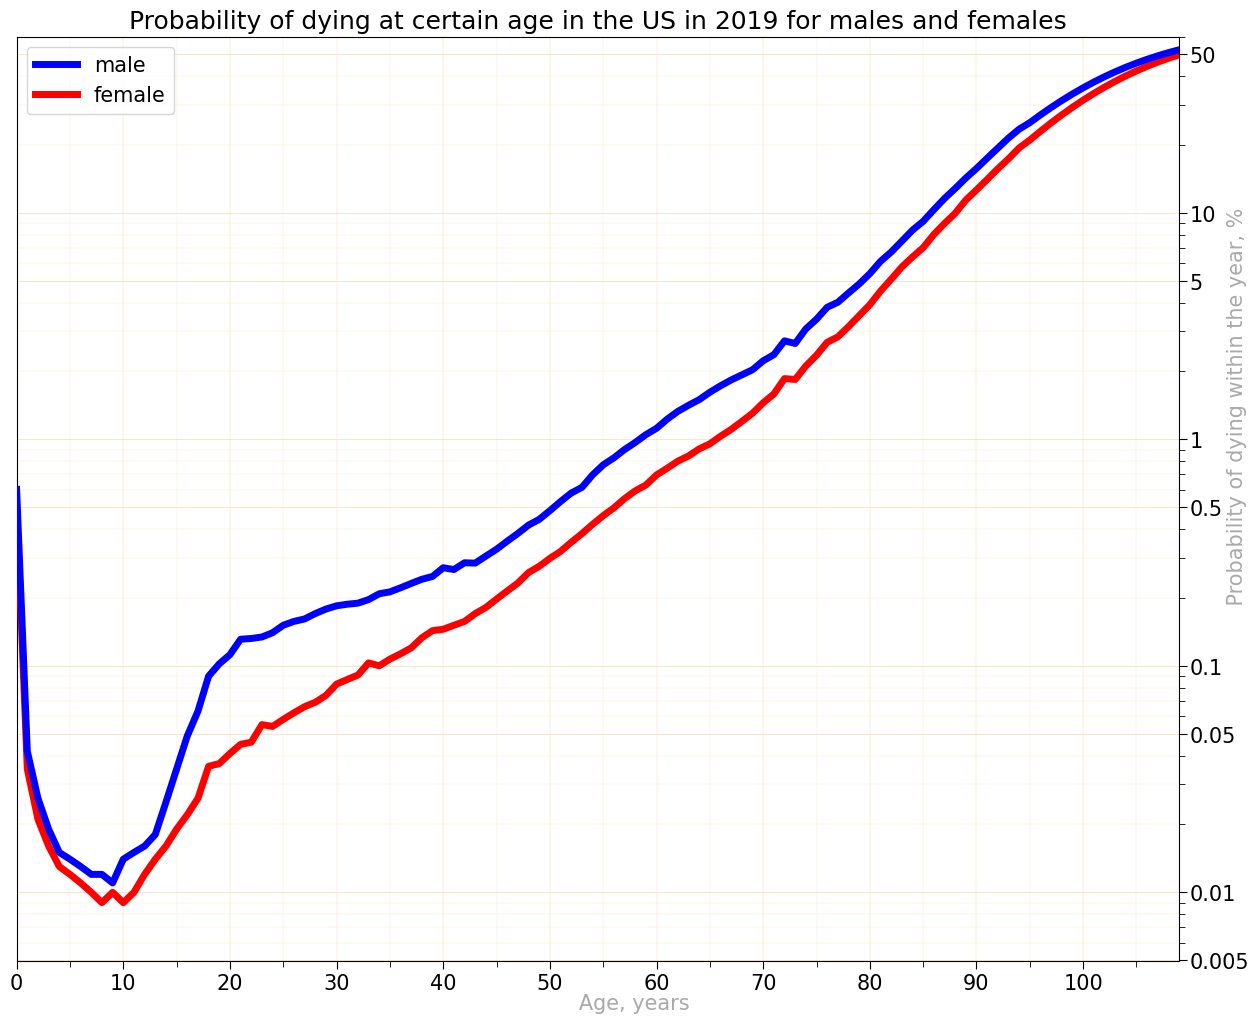

In [23]:
def create_chart_log(
        df, lang='en', dd_display='', ncol=1,
        plateau_years=plateau_years, age1=age1, age2=age2, show_plateau_lines=False,
        title_en="Title of the chart", title_ru="Заголовок графика",
        destination=DESTINATION_CHART, file_name=''):

    plt.rcParams['figure.figsize'] = (15, 12)
    
    fig, ax = plt.subplots()   # Create a figure and axis
    ax.set_yscale('log')       # Make Y-axis logarithmic  # alternative: plt.yscale('log')
    
    ax.yaxis.tick_right()      # show ticks only at the left side
    ax.yaxis.set_label_position('right')  # set the label position to the right 

    ax.xaxis.set_major_locator(MultipleLocator(10))   # Set major ticks to be multiples of 10
    ax.xaxis.set_minor_locator(MultipleLocator(5))    # Set minor ticks to be multiples of 5
    # ax.yaxis.set_major_locator(ticker.LogLocator())
    # ax.yaxis.set_minor_locator(ticker.LogLocator(subs=np.arange(1, 10) * 0.1))

    # Customize tick lengths
    ax.tick_params(axis='x', which='major', length=6, pad=3)   # Major ticks are longer
    ax.tick_params(axis='x', which='minor', length=4)          # Minor ticks are shorter
    ax.tick_params(axis='y', which='major', length=6, pad=1.5) # Major ticks are longer
    ax.tick_params(axis='y', which='minor', length=4)          # Minor ticks are shorter
    plt.xticks(fontsize=15)                                    # font size for tick labels
    labels_y = [0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]
    plt.yticks(ticks=labels_y, labels=labels_y, fontsize=15)
    
    x_min = y_min = 0
    x_max = 109
    y_max = 60
    plt.xlim(0, 109)
    plt.ylim(0.005, 60)

    plt.grid(which='major', axis='x', color='wheat', linewidth=0.35)
    plt.grid(which='major', axis='y', color='wheat', linewidth=0.5)
    plt.grid(which='minor', color='wheat', linewidth=0.20)

    # for y_milestone in [0.1, 1, 10]:
    #     plt.axhline(y=y_milestone, color='wheat', linewidth=0.5)

    plt.title(title_ru if lang=='ru' else " " if lang=='nolang' else title_en, fontsize=18)
    plt.xlabel("               Возраст, годы" if lang=='ru' else
               " " if lang=='nolang' else
               "           Age, years",
               fontsize=15, color='darkgray', labelpad=0)
    plt.ylabel("                   Вероятность смерти в течение года, %" if lang=='ru' else
               " " if lang=='nolang' else
               "                            Probability of dying within the year, %",
               fontsize=15, color='darkgray', labelpad=-16)
    
    for i, gr in enumerate(df.index.to_list()):
        ser = df.loc[gr]
        line_name = dd_display[gr].ru_name if lang=='ru' else dd_display[gr].nolang_name if lang=='nolang' else dd_display[gr].en_name
        plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
                 linewidth=dd_display[gr].width, label=line_name, alpha=dd_display[gr].alpha, zorder=100-i)

    if lang=='en':
        # Calculate and show statistics about "plateau" (21–30 years, including endpoints)
        # plateau_years = slice(21, 30)
        print(f"  —— The zone of the 'plateau' ({plateau_years.start}–{plateau_years.stop} years, incl.) ——")
        plateau_mortality_male   = df.loc['male', plateau_years].mean()
        plateau_mortality_female = df.loc['female', plateau_years].mean()
        print(f"Average mortality rate at the plateau, %:  ♂: {plateau_mortality_male:.3f},  ♀: {plateau_mortality_female:.3f}")
        le_average_plateau_male   = calculate_average_LE_if_mortality_as_at_plateau(plateau_mortality_male)
        le_average_plateau_female = calculate_average_LE_if_mortality_as_at_plateau(plateau_mortality_female)
        print(f"Average life expectancy, if the mortality rate was the same as at the plateau, years:  ♂: {round(le_average_plateau_male, -1)},  ♀: {round(le_average_plateau_female, -1)}")

        # Calculate and show statistics about the zone of the Gompertz law of mortality (40–90 years)
        # age1, age2 = 40, 90
        male_rate_perc, male_period_double = \
            calculate_increase_rate_and_doubling_period(age1, age2, df.loc['male', age1], df.loc['male', age2])
        female_rate_perc, female_period_double = \
            calculate_increase_rate_and_doubling_period(age1, age2, df.loc['female', age1], df.loc['female', age2])
        print(f"  —— The zone of the Gompertz law of mortality ({age1}–{age2} years) ——")
        print(f"♂: {male_rate_perc:5.2f} %/years,  doubling every {male_period_double:4.2f} years")
        print(f"♀: {female_rate_perc:5.2f} %/years,  doubling every {female_period_double:4.2f} years")

    if show_plateau_lines:  # show plateaux visually 
        for y_plateau in [plateau_mortality_male, plateau_mortality_female]:
             plt.hlines(y_plateau, plateau_years.start-5, plateau_years.stop+5, color='lime', linewidth=2, alpha=0.5)
    
    plt.legend(loc='upper left', fontsize=15, ncol=ncol)

    if destination == 'file':
        plt.savefig(f"output_charts/{file_name}{' -ru' if lang=='ru' else ' -nolang' if lang=='nolang' else ''}.png", bbox_inches='tight', facecolor='white', pad_inches=0.05)
        print("Data has written to file")
    else:
        plt.show()


dd_display = {
    'male'  : DisplayedGroup(en_name="male",    ru_name="мужчины", nolang_name="♂", color='blue',      style='-', width=5, alpha=1),
    # 'total' : DisplayedGroup(en_name="overall", ru_name="в целом", nolang_name="∑", color='lightgrey', style='-', width=5, alpha=1),
    'female': DisplayedGroup(en_name="female",  ru_name="женщины", nolang_name="♀", color='red',       style='-', width=5, alpha=1)
}

for lang in LANGS:
    create_chart_log(df.T.loc[['male', 'female']],
                 dd_display=dd_display, lang=lang,
                 plateau_years=plateau_years, age1=age1, age2=age2,
                 title_en=f"Probability of dying at certain age in the US in {YEAR} for males and females",  # , overall statistics for males and females
                 title_ru=f"Вероятность смерти в определённом возрасте в США в {YEAR} для мужчин и женщин",
                 file_name=f"Probability of Dying at Certain Age in the US in {YEAR} -log")

In [24]:
# play beep to denote completion of the program
import IPython.display as ipd
import numpy as np

# manually generated sound
t = 1  # time is seconds
beep = np.sin(2*np.pi*400*np.arange(10000*t)/10000)
ipd.Audio(beep, rate=10000, autoplay=True)